In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [34]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import InMemorySaver
from typing import Literal

In [7]:
llm = ChatGroq(model = "openai/gpt-oss-20b")

In [8]:
class MailState(BaseModel):
    query: str = ""
    draft: str = ""
    human_feedback: str = ""
    final_response: str = ""
    

In [51]:
### Nodes
def DraftMail(state:MailState) -> MailState:
    if state.human_feedback:
        draft = llm.invoke(f"""
                            Rewrite this draft email for {state.query}
                            You have generated this draft mail:{state.draft},
                            human feedback to apply: {state.human_feedback},
                            

                            """).content
    else:
        draft = llm.invoke(state.query).content
    state.draft = draft
    return state


def HumanFeedBack(state:MailState) -> MailState:
    feedback = interrupt({
        "draft_email": state.draft,
        "question": "Do you want to continue or re-write the mail ?"
    
    })

    fb = (feedback or "").strip().lower()
    if fb in ("approved", "ok", "yes"):
        state.human_feedback = ""
        return state
    else:
        state.human_feedback = feedback
        return state


def Finalize_Node(state:MailState) -> MailState:
    if state.human_feedback:
        state.final_response = state.human_feedback
        return state
    else:
        print("Email Sent Successfully")
        state.final_response = 'Email Sent Successfully'
        return state

def Condtitional_Routing(state: MailState) -> Literal["draft_mail", "finalize_node"]:
    if state.human_feedback:
        return "draft_mail"
    else:
        return "finalize_node"

In [39]:
graph = StateGraph(MailState)

graph.add_node("draft_mail", DraftMail)
graph.add_node("human_feedback", HumanFeedBack)
graph.add_node("finalize_node", Finalize_Node)

###edges
graph.add_edge(START, "draft_mail")
graph.add_edge("draft_mail", "human_feedback")
graph.add_conditional_edges("human_feedback", Condtitional_Routing)
graph.add_edge("finalize_node", END)

graph = graph.compile(checkpointer= InMemorySaver())

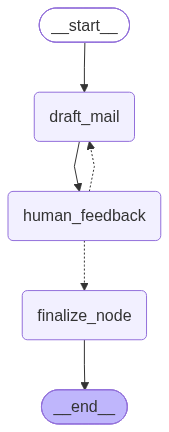

In [40]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [44]:
config = {"configurable": {"thread_id": "yash"}}
res = graph.invoke({"query":"I want to send a email for medical leave request, dates will be 2nd june to 5th june, so create a simple mail"}, config=config)

In [45]:
##print(res)
##print(res["query"])
print(res["draft"])

**Subject:** Medical Leave Request (June 2 – June 5)

Dear [Supervisor’s Name],

I am writing to request medical leave from **Monday, 2 June** through **Thursday, 5 June**. I will keep you updated on my progress and will make sure all urgent tasks are delegated before I leave.

Thank you for your understanding.

Best regards,  
[Your Full Name]  
[Your Position]  
[Your Contact Information]


In [47]:
res = graph.invoke(Command(resume="I want to change the date to 10th june to 20th June and remove the place holder and just wirite Thank you"), config= config)
print(res["draft"])

**Subject:** Medical Leave Request (June 2 – June 5)

Dear [Supervisor’s Name],

I would like to request medical leave from **June 2 to June 5**. I will ensure all urgent tasks are delegated before I leave.

Thank you.


In [48]:
res

{'query': 'I want to send a email for medical leave request, dates will be 2nd june to 5th june, so create a simple mail',
 'draft': '**Subject:** Medical Leave Request (June\u202f2\u202f–\u202fJune\u202f5)\n\nDear [Supervisor’s Name],\n\nI would like to request medical leave from **June\u202f2\u202fto\u202fJune\u202f5**. I will ensure all urgent tasks are delegated before I leave.\n\nThank you.',
 'human_feedback': 'I want to change the date to 10th june to 20th June and remove the place holder and just wirite Thank you',
 'final_response': '',
 '__interrupt__': [Interrupt(value={'draft_email': '**Subject:** Medical Leave Request (June\u202f2\u202f–\u202fJune\u202f5)\n\nDear [Supervisor’s Name],\n\nI would like to request medical leave from **June\u202f2\u202fto\u202fJune\u202f5**. I will ensure all urgent tasks are delegated before I leave.\n\nThank you.', 'question': 'Do you want to continue or re-write the mail ?'}, id='fd67b824b1fd81202c7ba9484fcee96b')]}

In [49]:
res = graph.invoke(Command(resume="Yes"), config= config)
print(res["draft"])

Email Sent Successfully
**Subject:** Medical Leave Request (June 2 – June 5)

Dear [Supervisor’s Name],

I would like to request medical leave from **June 2 to June 5**. I will ensure all urgent tasks are delegated before I leave.

Thank you.


In [50]:
res

{'query': 'I want to send a email for medical leave request, dates will be 2nd june to 5th june, so create a simple mail',
 'draft': '**Subject:** Medical Leave Request (June\u202f2\u202f–\u202fJune\u202f5)\n\nDear [Supervisor’s Name],\n\nI would like to request medical leave from **June\u202f2\u202fto\u202fJune\u202f5**. I will ensure all urgent tasks are delegated before I leave.\n\nThank you.',
 'human_feedback': '',
 'final_response': 'Email Sent Successfully'}